<a href="https://colab.research.google.com/github/TubaSatoglu/Stellar-Classification-Using-ML-Approaches/blob/main/Stellar_Classification_Using_ML_Approaches.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas numpy matplotlib  catboost tensorflow seaborn shap tensorflow scikit-learn torch torchvision numpy pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 2.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.neural_network import MLPClassifier
import shap
import time
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.ensemble import StackingClassifier
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from google.colab import drive


Mounted at /content/drive


In [ ]:
drive.mount('/content/drive')
output_file = '/content/drive/MyDrive/Y_LRS_OBAFGKM_A+0.csv'
df = pd.read_csv(output_file,delimiter=",")
df=pd.DataFrame(df)


ddf.columns = ddf.columns.astype(str).str.replace(r'\[', '', regex=True).str.replace(r'\]', '', regex=True)
df = ddf.dropna(subset=['class'], how='any')  # Drop rows where 'class' is NaN=df.dropna(df['class']=="nan")
random_50_percent = new_df.sample(frac=0.5, random_state=42)
remaining_50_percent = new_df.drop(random_50_percent.index)

### **Data Preprocessing**

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def modify_o_class_subclass(df, class_column, subclass_column, o_subclass_target=181):
    modified_df = df.copy()
    modified_df.loc[modified_df[class_column] == 'O', subclass_column] = o_subclass_target
    return modified_df

class_column = 'class'
subclass_column = 'subclass_value'
o_subclass_target = 181

new_df = modify_o_class_subclass(random_50_percent, class_column, subclass_column, o_subclass_target)

X = new_df.drop(columns=["class", "subclass", "type", "subclass_value"])
y = new_df['class']

X = X.dropna()
y = y.loc[X.index]

X = X.select_dtypes(include=['number'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

# Dimensionality reduction via LDA
lda = LDA(n_components=min(len(np.unique(y_encoded)) - 1, X_train.shape[1]))
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

Training Model with Class Weights...
Epoch [1/12], Loss: 0.3608
Epoch [2/12], Loss: 0.3011
Epoch [3/12], Loss: 0.2896
Epoch [4/12], Loss: 0.2864
Epoch [5/12], Loss: 0.2818
Epoch [6/12], Loss: 0.2818
Epoch [7/12], Loss: 0.2831
Epoch [8/12], Loss: 0.2773
Epoch [9/12], Loss: 0.2739
Epoch [10/12], Loss: 0.2769
Epoch [11/12], Loss: 0.2738
Epoch [12/12], Loss: 0.2720


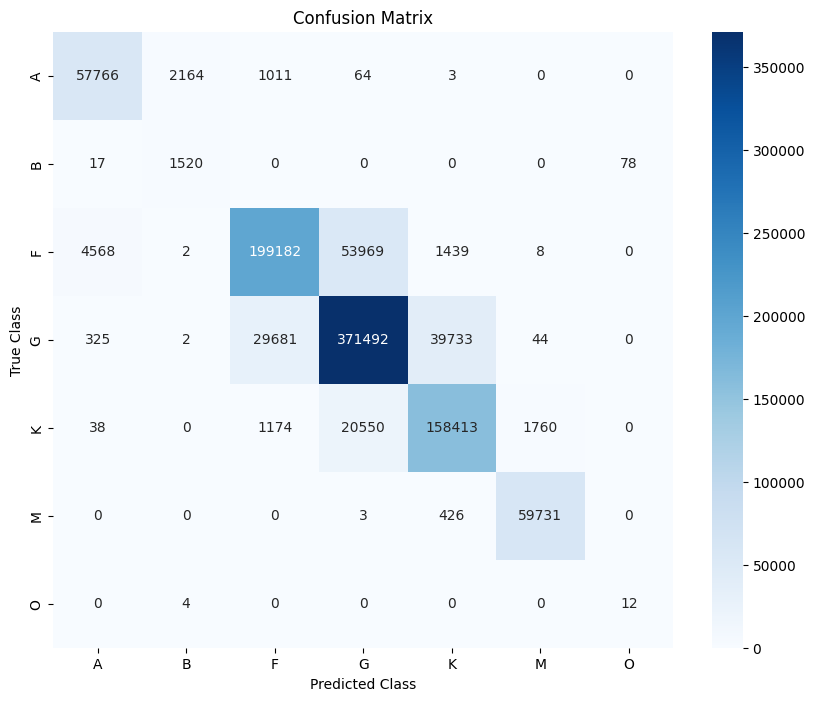


Classification Report:
              precision    recall  f1-score   support

           A       0.92      0.95      0.93     61008
           B       0.41      0.94      0.57      1615
           F       0.86      0.77      0.81    259168
           G       0.83      0.84      0.84    441277
           K       0.79      0.87      0.83    181935
           M       0.97      0.99      0.98     60160
           O       0.13      0.75      0.23        16

    accuracy                           0.84   1005179
   macro avg       0.70      0.87      0.74   1005179
weighted avg       0.85      0.84      0.84   1005179

Accuracy: 84.37%


In [ ]:
X_train_tensor = torch.tensor(X_train_lda, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_lda, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

# Compute inverse class weights to handle imbalance
class_sample_count = np.bincount(y_train)
class_weights = 1. / class_sample_count
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)


class StarDeepNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(StarDeepNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(0.4)

        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)

        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)

        self.fc4 = nn.Linear(64, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.relu(self.bn3(self.fc3(x)))
        x = self.fc4(x)
        return x


input_dim = X_train_lda.shape[1]
num_classes = len(np.unique(y_encoded))

model = StarDeepNN(input_dim, num_classes)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)


def train_with_class_weights(model, loader, criterion, optimizer, epochs=12):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for features, labels in loader:
            optimizer.zero_grad()
            outputs = model(features)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {total_loss / len(loader):.4f}")


print("Training Model with Class Weights...")
train_with_class_weights(model, train_loader, criterion, optimizer)


def evaluate_model(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for features, labels in loader:
            outputs = model(features)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)


y_pred, y_true = evaluate_model(model, test_loader)
class_names = le.inverse_transform(range(num_classes))


def plot_confusion_matrix(y_true, y_pred, class_names):
    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d",
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.show()


plot_confusion_matrix(y_true, y_pred, class_names)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

### **Shapley Values**

---




Computing SHAP values for LDA components...


  0%|          | 0/150 [00:00<?, ?it/s]


SHAP Summary Plot for Original Features


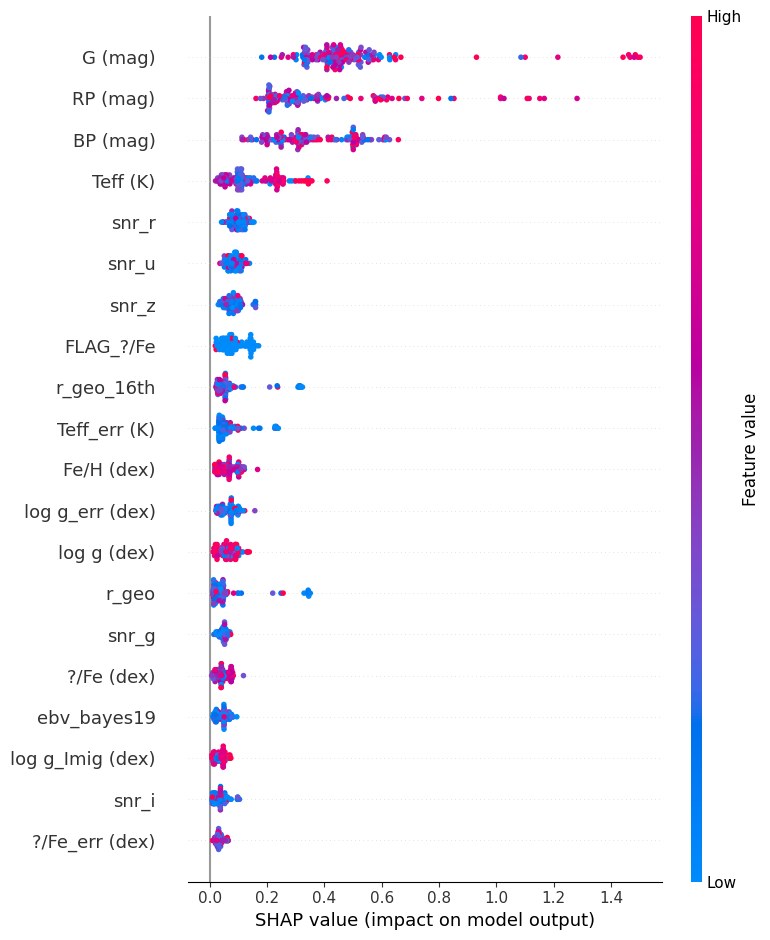

In [ ]:
print("\nComputing SHAP values for LDA components...")
import torch.nn.functional as F

num_samples = 150
background_size = 50

X_test_lda_sample = X_test_lda[:num_samples]
background = X_train_lda[np.random.choice(X_train_lda.shape[0], background_size, replace=False)]

lda_coefficients = lda.scalings_

def predict_wrapper_pytorch(data_numpy):
    data_torch = torch.tensor(data_numpy, dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        logits = model(data_torch)
        probs = F.softmax(logits, dim=1)
    return probs.cpu().numpy()

explainer = shap.KernelExplainer(predict_wrapper_pytorch, background)
shap_values = explainer.shap_values(X_test_lda_sample)

if len(np.array(shap_values).shape) == 3:
    shap_arr = np.array(shap_values)

    if shap_arr.shape[0] == num_samples:
        n_samples2, n_classes2, n_components2 = shap_arr.shape
    else:
        n_classes2, n_samples2, n_components2 = shap_arr.shape
        shap_arr = shap_arr.transpose((1, 0, 2))

    shap_values_sum = np.zeros((n_samples2, lda_coefficients.shape[0]))

    for class_idx in range(n_classes2):
        shap_values_class = shap_arr[:, class_idx, :]

        if shap_values_class.shape[1] > lda_coefficients.T.shape[0]:
            shap_values_class = shap_values_class[:, :lda_coefficients.T.shape[0]]
        elif shap_values_class.shape[1] < lda_coefficients.T.shape[0]:
            padding = lda_coefficients.T.shape[0] - shap_values_class.shape[1]
            shap_values_class = np.pad(
                shap_values_class, ((0, 0), (0, padding)), 'constant'
            )

        # Mapping back to the original feature space
        shap_vals_orig = np.dot(shap_values_class, lda_coefficients.T)
        shap_values_sum += np.abs(shap_vals_orig)

    shap_values_mean = shap_values_sum / n_classes2
else:
    shap_values_mean = None
    print("Unexpected shape of shap_values.")


X_test_scaled = X_test
feature_names = X.columns

print("\nSHAP Summary Plot for Original Features")
if shap_values_mean is not None:
    shap.summary_plot(
        shap_values_mean,
        X_test_scaled[:num_samples],
        feature_names=feature_names
    )
else:
    print("shap_values_mean is None, cannot plot.")

### **Creating file in drive**

In [ ]:
import os
from google.colab import drive

drive.mount('/content/drive')
folder_path = '/content/drive/MyDrive/son'
os.makedirs(folder_path, exist_ok=True)

print(f"Folder '{folder_path}' created (or already exists).")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder '/content/drive/MyDrive/son' created (or already exists).


### **Register model**

In [ ]:
import joblib
import torch
model_save_path = '/content/drive/MyDrive/son/Son_model_save'
scaler_save_path = "/content/drive/MyDrive/son/scaler.pkl"
lda_save_path = "/content/drive/MyDrive/son/lda.pkl"
label_encoder_save_path = "/content/drive/MyDrive/son/label_encoder.pkl"
torch.save(model.state_dict(), model_save_path)

# Scaler, LabelEncoder and LDA
joblib.dump(scaler, scaler_save_path)
joblib.dump(le, label_encoder_save_path)
joblib.dump(lda, lda_save_path)

print("Model, Scaler, LabelEncoder ve LDA kayıt edildi.")

Model, Scaler, LabelEncoder ve LDA kayıt edildi.


In [ ]:
loaded_model = StarDeepNN(input_dim=input_dim, num_classes=num_classes)
loaded_model.load_state_dict(torch.load(model_save_path))
loaded_model.eval()

scaler_loaded = joblib.load(scaler_save_path)
le_loaded = joblib.load(label_encoder_save_path)
lda_loaded = joblib.load(lda_save_path)

print("Model, Scaler, LabelEncoder ve LDA başarıyla yüklendi.")

Model, Scaler, LabelEncoder ve LDA başarıyla yüklendi.


<ipython-input-12-b7ab699d6bb6>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(model_save_path))


### **Train Model with New Data and Project Results**



Tahmin edilen sınıflar: ['M' 'B' 'F' ... 'G' 'A' 'K']
True classes length: 5025655
Predicted classes length: 5025655
Adjusted true classes length: 5025655
Predicted classes length: 5025655


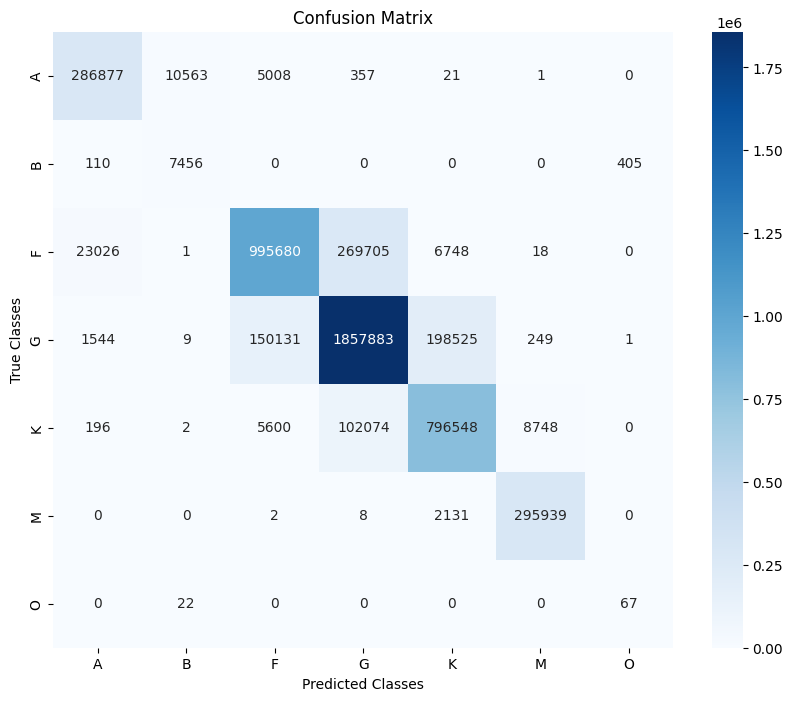

Accuracy: 0.8438

Classification Report:
              precision    recall  f1-score   support

           A       0.92      0.95      0.93    302827
           B       0.41      0.94      0.57      7971
           F       0.86      0.77      0.81   1295178
           G       0.83      0.84      0.84   2208342
           K       0.79      0.87      0.83    913168
           M       0.97      0.99      0.98    298080
           O       0.14      0.75      0.24        89

    accuracy                           0.84   5025655
   macro avg       0.70      0.87      0.74   5025655
weighted avg       0.85      0.84      0.84   5025655



In [ ]:
def modify_o_class_subclass(df, class_column, subclass_column, o_subclass_target=181):
    modified_df = df.copy()
    modified_df.loc[modified_df[class_column] == 'O', subclass_column] = o_subclass_target
    return modified_df


class_column = 'class'
subclass_column = 'subclass_value'
o_subclass_target = 181

new_df = modify_o_class_subclass(remaining_50_percent, class_column, subclass_column, o_subclass_target)
df_new = new_df
new_X = df_new.drop(columns=["class", "subclass", "type", "subclass_value"])

new_X = new_X.dropna()
df_new = df_new.dropna(subset=['class'])

new_X = new_X.select_dtypes(include=["number"])

new_X_scaled = scaler_loaded.transform(new_X)
new_X_lda = lda_loaded.transform(new_X_scaled)

new_X_tensor = torch.tensor(new_X_lda, dtype=torch.float32)

loaded_model.eval()
with torch.no_grad():
    outputs = loaded_model(new_X_tensor)
    _, predictions = torch.max(outputs, 1)

predicted_classes = le_loaded.inverse_transform(predictions.numpy())
print("Tahmin edilen sınıflar:", predicted_classes)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

predicted_classes = le_loaded.inverse_transform(predictions.numpy())
true_classes = df_new.loc[new_X.index, 'class'].values

print(f"True classes length: {len(true_classes)}")
print(f"Predicted classes length: {len(predicted_classes)}")

print(f"Adjusted true classes length: {len(true_classes)}")
print(f"Predicted classes length: {len(predicted_classes)}")

conf_matrix = confusion_matrix(true_classes, predicted_classes, labels=le_loaded.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=le_loaded.classes_, yticklabels=le_loaded.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Classes")
plt.ylabel("True Classes")
plt.show()

accuracy = accuracy_score(true_classes, predicted_classes)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=le_loaded.classes_))